In [1]:
# Import required libraries
import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.append(os.path.abspath("../"))

# Import gref4hsi modules
from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

# Import NDI analysis utilities
from utils.ndi_analysis_utils import *

In [2]:
# Load 028 transect
transect = load_transect(r"E:\mjosa_new_oct_2025\use_gref4hsi\028\output")
transect.list_files()

# Select 028_5 for NDI analysis
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
# cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
   • rad_uhi_

In [3]:
# %matplotlib qt

In [10]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.00000000e+00, 8.00363868e-02, 3.38807702e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.79862548e-03, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.24412894e-01, 0.00000000e+00, ...,
         2.43312144e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.49576187e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.18552887e+00, ...,
         2.34972164e-01, 0.00000000e+00, 0.00000000e+00],
        [9.47257459e-01, 0.00000000e+00, 0.00000000e+00, ...,
         3.01917344e-01, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.15298668e+02, 1.14839525e+01, 3.45664215e-03],
        [0.00000000e+00, 1.00000000e+00, 9.11504328e-01, ...,
         2.32659373e-02, 2.43540382e+00, 4.57144403e+00],
        [0.00000000e+00, 

💡 Interactive mode: Click on the plot to display coordinates


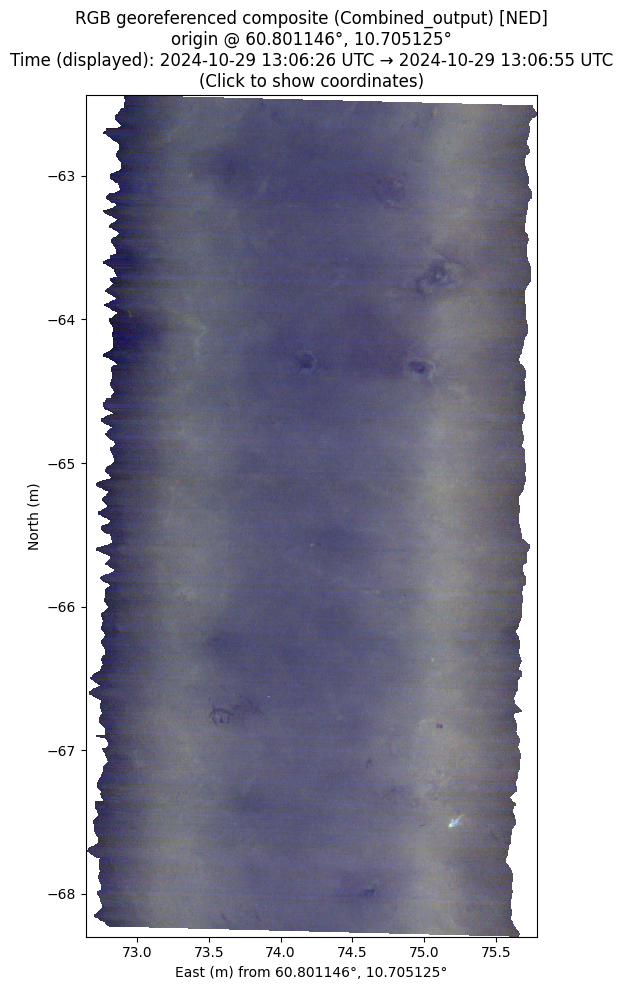

In [5]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=False,
    coordinate_system="NED",
    figsize=(40, 10),
    track_start=8980,
    track_end=9565,
)

📐 Aspect ratio correction: 3.50:1 (track:slit)
   Slit pixels: 400, Track pixels: 114
🔍 Crop applied: track [5535:5649], slit [565:965]
   Resulting shape: (114, 400, 3)
📊 Extent: x=[565, 965], y=[5535, 5649]
📐 Image shape after transformations: (114, 400, 3)


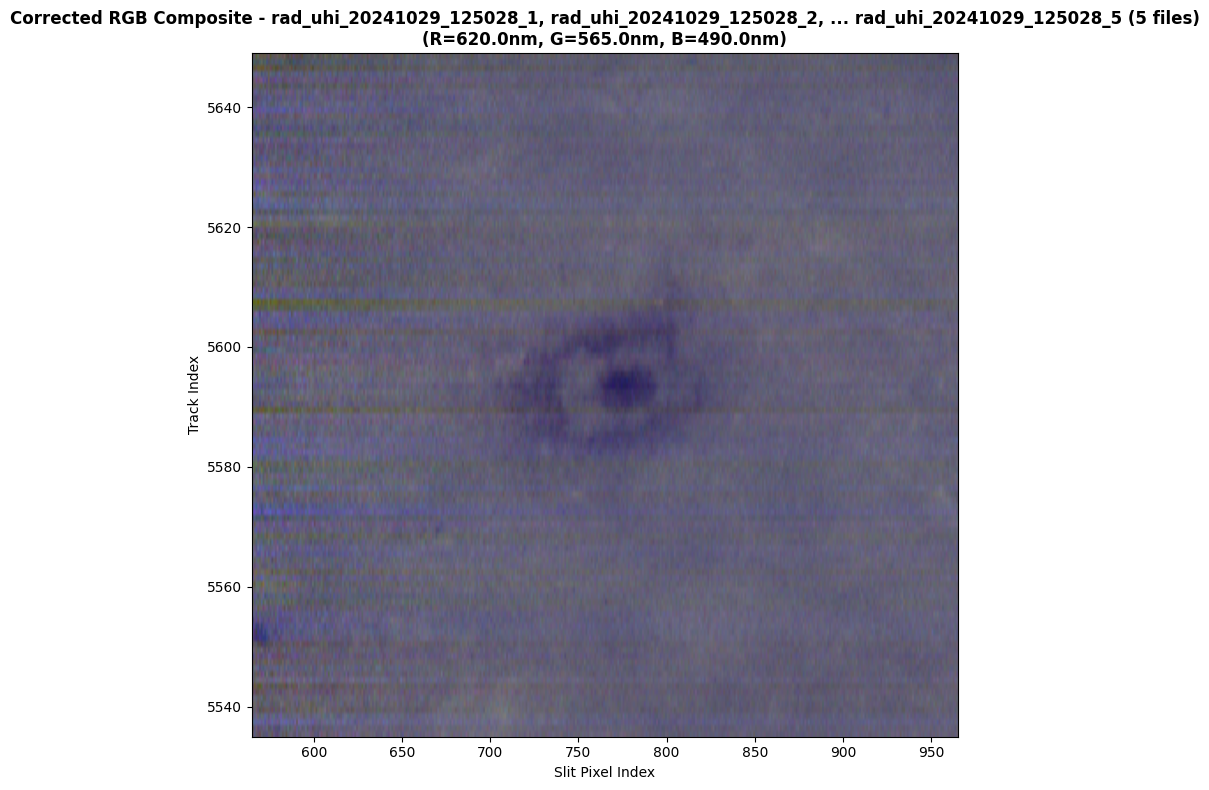

In [18]:
cube.plot_rgb(
    use_corrected=True,
    flip_axes=True,
    # figsize=(3, 10),
    flip_horizontal=True,
    crop_center_track=5592,
    crop_center_slit=765,
    crop_width=400,
    show_file_boundaries=False,
    crop_aspect_ratio=3.5,
)

📐 Aspect ratio correction: 3.50:1 (track:slit)
   Slit pixels: 400, Track pixels: 114
🔍 Crop applied: track [1201:1315], slit [12:412]
   Resulting shape: (114, 400, 3)
📊 Extent: x=[12, 412], y=[1201, 1315]
📐 Image shape after transformations: (114, 400, 3)


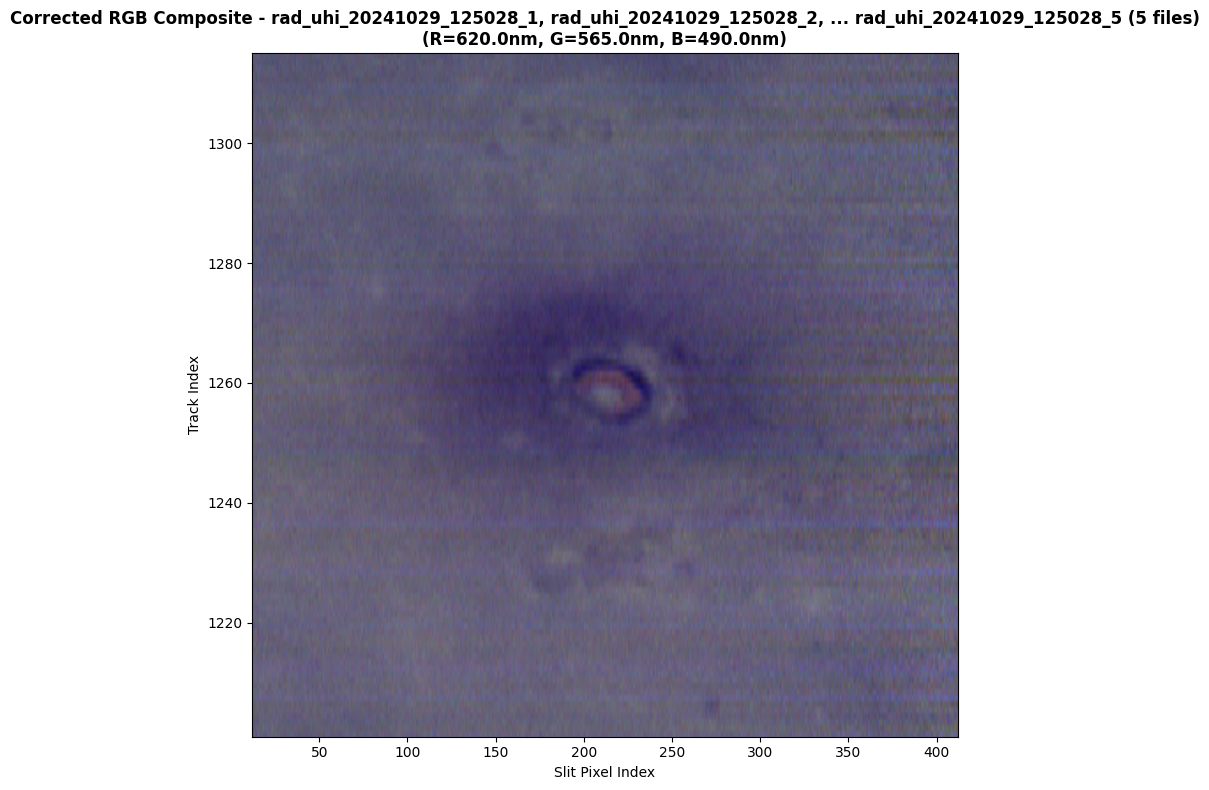

In [19]:
cube.plot_rgb(
    use_corrected=True,
    flip_axes=True,
    # figsize=(3, 10),
    flip_horizontal=True,
    crop_center_track=1258,
    crop_center_slit=212,
    crop_width=400,
    show_file_boundaries=False,
    crop_aspect_ratio=3.5,
)

📐 Aspect ratio correction: 3.50:1 (track:slit)
   Slit pixels: 400, Track pixels: 114
🔍 Crop applied: track [5103:5217], slit [413:813]
   Resulting shape: (114, 400, 3)
📊 Extent: x=[413, 813], y=[5103, 5217]
📐 Image shape after transformations: (114, 400, 3)


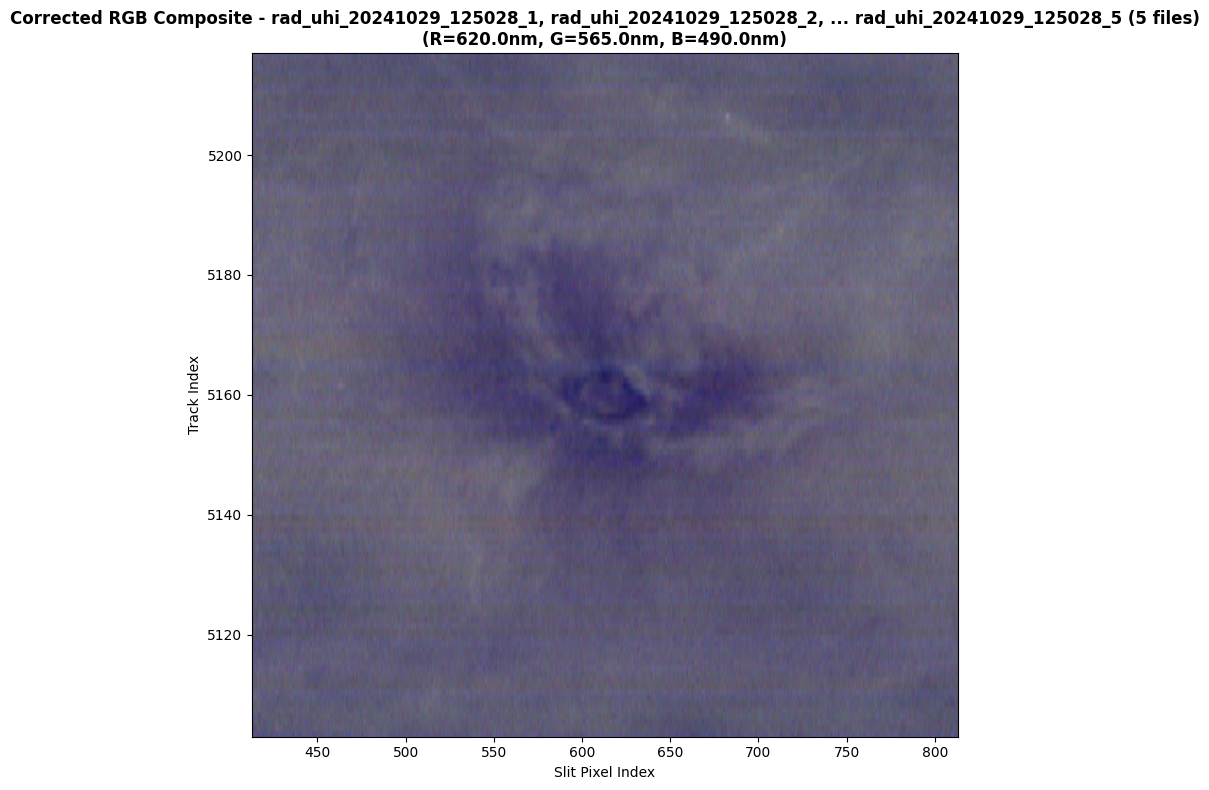

In [20]:
cube.plot_rgb(
    use_corrected=True,
    flip_axes=True,
    # figsize=(3, 10),
    flip_horizontal=True,
    crop_center_track=5160,
    crop_center_slit=613,
    crop_width=400,
    show_file_boundaries=False,
    crop_aspect_ratio=3.5,
)